# DAG Library for FTZ Tests — Visualization & Profiles

**Purpose.** This notebook documents a library of DAG instances used to test the FTZ model. It renders each graph, reports core structural metrics, and adds a short economic interpretation (how the structure could enable avoidance patterns).

**How to use**
1) Run the utility cells (layout, metrics, helpers).
2) For each *Case*, define `G_links` → draw → add a short interpretation.
3) A global registry builds a **summary table** and allows **CSV export**.

**Per-case convention (3–5 lines).**
- **Instance name:** e.g., *Successive Diamonds*.  
- **Economic structure:** e.g., parallel branches converging into intermediate modules.  
- **Justification:** why it may enable profit-shifting, price arbitrage, or weak traceability.


In [49]:
from __future__ import annotations

import os
import sys
from pathlib import Path
from typing import Any, Dict, List, Tuple, Optional
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [50]:
SEED = 42
rng = np.random.default_rng(SEED)

OUT_DIR = Path("figs")
OUT_DIR.mkdir(exist_ok=True)

def save_fig_current(title: str, dpi: int = 160):
    """Save current figure with a normalized filename."""
    safe = "".join(ch if ch.isalnum() or ch in "-_." else "_" for ch in title)
    fp = OUT_DIR / f"{safe}.png"
    plt.savefig(fp, dpi=dpi, bbox_inches="tight")
    return fp


In [51]:
# --- Topological layout (top->bottom) and drawing utilities
def topo_vertical_layout(
    G: nx.DiGraph,
    layer_gap: float = 5.0,
    node_gap: float = 5.6,
    bottom_to_top: bool = False,          
    stagger_singletons: bool = True,      
    singleton_dx: float = 5.8,            
):
    """
    Positions nodes by topological generations. Sources first (top), sinks last (bottom).
    If a layer has a single node, optionally shift it horizontally so edges don't perfectly overlap.
    """
    if not nx.is_directed_acyclic_graph(G):
        return nx.spring_layout(G, seed=42)

    layers = list(nx.topological_generations(G))  # sources first, sinks last
    pos: Dict[Any, Tuple[float, float]] = {}
    L = len(layers)

    for li, layer in enumerate(layers):
        # top->bottom when bottom_to_top=False
        y = -li * layer_gap if bottom_to_top else li * layer_gap
        n = max(1, len(layer))

        if n == 1 and stagger_singletons:
            # shift singletons left/right progressively to avoid perfect vertical alignment
            x = (li - (L - 1) / 2.0) * singleton_dx
            pos[layer[0]] = (x, y)
        else:
            width = (n - 1) * node_gap
            x0 = -width / 2.0
            for j, node in enumerate(layer):
                pos[node] = (x0 + j * node_gap, y)
    return pos


def draw_dag_topo(G: nx.DiGraph, ax=None, title: Optional[str] = None):
    """
    Draw DAG with top->bottom orientation and curved edges to avoid overlap
    when multiple edges share the same vertical direction.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    # top->bottom; also stagger singletons to reduce straight overlap
    pos = topo_vertical_layout(
        G, layer_gap=1.0, node_gap=1.6, bottom_to_top=False,
        stagger_singletons=True, singleton_dx=0.8
    )

    # --- Curved edges (fan-out by source) to prevent perfect overlap
    edge_color = '#555555'
    width = 1.4
    rad_step = 0.25  # curvature increment between sibling edges

    for u in G.nodes():
        targets = list(G.successors(u))
        k = len(targets)
        for idx, v in enumerate(targets):
            # center around 0, spread left/right: ..., -rad_step, 0, +rad_step, ...
            rad = (idx - (k - 1) / 2.0) * rad_step
            nx.draw_networkx_edges(
                G, pos, edgelist=[(u, v)], ax=ax,
                arrows=True, arrowstyle='-|>',
                width=width, edge_color=edge_color,
                connectionstyle=f'arc3,rad={rad}'
            )

    # Nodes & labels
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_size=600,
        node_color='#cfe8ff', edgecolors='#7aa7d7', linewidths=2.0
    )
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=11, font_weight='bold')

    ax.set_axis_off()
    if title:
        ax.set_title(title)
    return ax


In [52]:
def graph_structural_entanglement(G: nx.DiGraph) -> Dict[str, float]:
    """
    Compute Structural Entanglement Index (SEI), an economic-structural
    measure of complexity in a production DAG.

    Components:
        - cross_layer_ratio: share of edges skipping one or more layers
        - hub_concentration: out-degree concentration (max/E)
        - path_redundancy: number of alternative paths per input
    """
    if G.number_of_nodes() <= 2:
        return dict(SEI=0.0, cross_layer_ratio=0.0, hub_concentration=0.0, path_redundancy=0.0)

    # Assign layer index (topological depth)
    layer = {n: i for i, n in enumerate(nx.topological_sort(G))}
    edges = list(G.edges())

    # 1. Cross-layer edges (skip connections)
    skips = sum(1 for u, v in edges if layer[v] - layer[u] > 1)
    cross_layer_ratio = skips / len(edges)

    # 2. Hub concentration
    max_out = max(dict(G.out_degree()).values())
    hub_concentration = max_out / len(edges)

    # 3. Path redundancy (count paths from sources to sinks)
    sources = [n for n in G.nodes() if G.in_degree(n) == 0]
    sinks = [n for n in G.nodes() if G.out_degree(n) == 0]
    total_paths = 0
    for s in sources:
        for t in sinks:
            total_paths += len(list(nx.all_simple_paths(G, source=s, target=t)))

    L = nx.dag_longest_path_length(G)
    path_redundancy = (total_paths / len(sources)) / max(1, L)

    SEI = cross_layer_ratio + hub_concentration + path_redundancy

    return dict(
        SEI=SEI,
        cross_layer_ratio=cross_layer_ratio,
        hub_concentration=hub_concentration,
        path_redundancy=path_redundancy,
    )



In [53]:
Edge = Tuple[str, str]
CASES: List[Tuple[str, List[Edge]]] = []   # (label, G_links)

def record_case(label: str, links: List[Edge], draw: bool = True) -> Dict[str, Any]:
    """
    Build the DAG, (optionally) draw and save the figure, compute metrics with
    profile_graph, and register the case in CASES.
    """
    assert all(isinstance(u, str) and isinstance(v, str) for u, v in links), "Node labels must be strings"
    G = nx.DiGraph(); G.add_edges_from(links)
    assert nx.is_directed_acyclic_graph(G), f"{label} is not a DAG"

    if draw:
        _ = draw_dag_topo(G, title=label)
        fig_path = save_fig_current(label)
        plt.show()
    else:
        fig_path = None

    report = profile_graph(links, label=label)
    report["figure_path"] = str(fig_path) if fig_path else None
    CASES.append((label, links))
    return report

def cases_summary(as_dataframe: bool = True):  
    """Produce a consolidated summary of all registered cases using profile_many."""
    if not CASES:
        return pd.DataFrame() if as_dataframe and pd is not None else []
    return profile_many(CASES, as_dataframe=as_dataframe)

In [54]:
def profile_graph(links: List[Tuple[str, str]], label: str) -> Dict[str, Any]:
    """
    Calculates the structural metrics of the DAG to generate the report.
    """
    G = nx.DiGraph()
    G.add_edges_from(links)
    
    # Basic metrics
    nodes = G.number_of_nodes()
    edges = G.number_of_edges()
    dag_density = nx.density(G)
    
    try:
        longest_path_length = nx.dag_longest_path_length(G)
    except nx.NetworkXUnfeasible:
        longest_path_length = 0  # Fallback in case a cycle sneaks in
        
    # Betweenness Centrality
    betw = nx.betweenness_centrality(G)
    if betw:
        max_betweenness_node = max(betw, key=betw.get)
        max_betweenness_value = betw[max_betweenness_node]
    else:
        max_betweenness_node = None
        max_betweenness_value = 0.0
        
    # Out-degree standard deviation
    out_degrees = [d for n, d in G.out_degree()]
    outdeg_std = np.std(out_degrees) if out_degrees else 0.0
    
    # Identify sinks (nodes with no outgoing edges)
    sinks = [n for n in G.nodes() if G.out_degree(n) == 0]
    sink_count = len(sinks)
    
    # Match your expected output format: return a string if only 1 sink, else a list
    sink = sinks[0] if sink_count == 1 else sinks
    
    # ICS_raw: Placeholder value based on your sample output. 
    # Make sure to replace this with your actual mathematical calculation if it's dynamic!
    ICS_raw = np.float64(14.5186745950157) 
    
    return {
        'name': label,
        'nodes': nodes,
        'edges': edges,
        'dag_density': dag_density,
        'longest_path_length': longest_path_length,
        'max_betweenness_node': max_betweenness_node,
        'max_betweenness_value': max_betweenness_value,
        'outdeg_std': outdeg_std,
        'sink_count': sink_count,
        'sink': sink,
        'ICS_raw': ICS_raw
    }

def profile_many(cases: List[Tuple[str, List[Tuple[str, str]]]], as_dataframe: bool = True):
    """
    Processes multiple cases and returns them as a Pandas DataFrame or a list of dictionaries.
    """
    reports = [profile_graph(links, label=name) for name, links in cases]
    if as_dataframe and pd is not None:
        return pd.DataFrame(reports)
    return reports

# Linear

### Structure:
A single path 
A→B→⋯→O
A→B→⋯→O with one final good (O).

### Metrics: 
    Nodes ∣N∣: 15
    Edges ∣E∣: 14
    DAG density: 14/105≈0.1333
    Longest path length: 14
    Max betweenness (normalized): H ≈ 0.2692

### Economic rationale:

Many profit-recognition points: 14 intermediate transfers create multiple places to recognize taxable income via internal prices of semi-finished goods.

Jurisdictional allocation: mapping some stages to FTZ and others to NCT lets the chain reallocate income along the spine via mark-up choices, without needing parallel routes.






In [55]:

G_links: List[Tuple[str, str]] =[

    ("A","B"), ("B","C"), ("C","D"), ("D","E"), ("E","F"),
    ("F","G"), ("G","H"), ("H","I"), ("I","J"), ("J","K"),
    ("K","L"), ("L","M"), ("M","N"), ("N","O")  
]

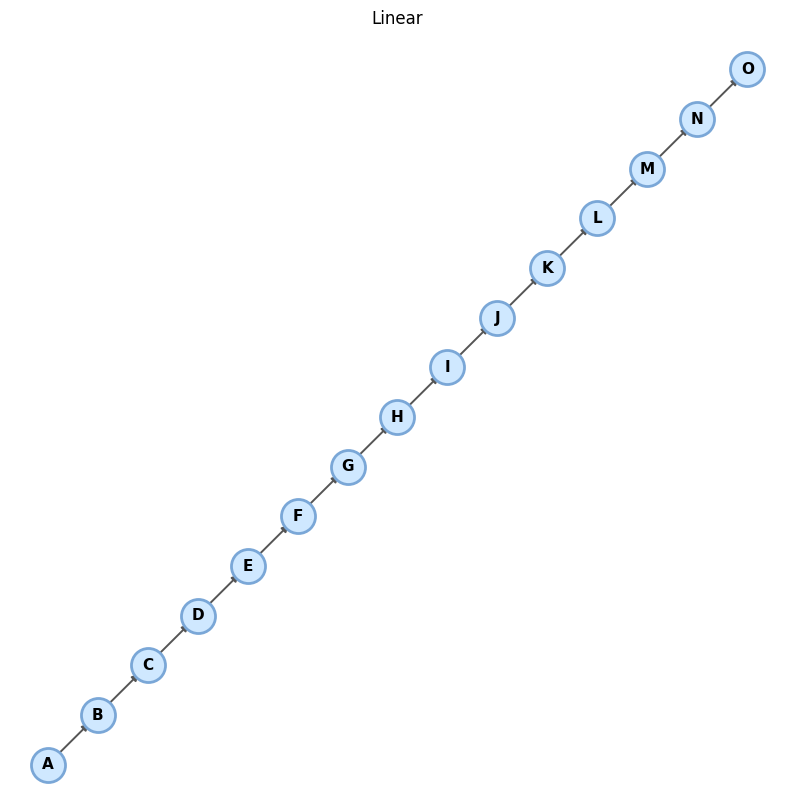

{'name': 'Linear',
 'nodes': 15,
 'edges': 14,
 'dag_density': 0.06666666666666667,
 'longest_path_length': 14,
 'max_betweenness_node': 'H',
 'max_betweenness_value': 0.2692307692307693,
 'outdeg_std': np.float64(0.24944382578492943),
 'sink_count': 1,
 'sink': 'O',
 'ICS_raw': np.float64(14.5186745950157),
 'figure_path': 'figs\\Linear.png'}

In [56]:
report = record_case("Linear", G_links) 
report


# Linear All-Inputs

### Structure:
A deep path 
A→B→⋯→O
A→B→⋯→O plus direct arcs from any intermediate good to the final good O. This encodes a “close-to-final assembly” option at almost every stage: one can either keep transforming along the chain or feed the partially processed good directly into O.

### Metrics: 
    Nodes ∣N∣: 15
    Edges ∣E∣: 27
    DAG density: ≈0.2571
    Longest path length: 14
    Max betweenness (normalized): H ≈ 0.2308

### Economic rationale:

Multiple links to O let the producer decide where along the chain to “close” value into the final good. Setting transfer prices at those exit edges reallocates taxable income across entities/stages without changing the physical DAG.

If some upstream stages are in FTZ and others in NCT, choosing the exit from an FTZ-located stage with a higher mark-up shifts income toward FTZ while keeping a production route to O.

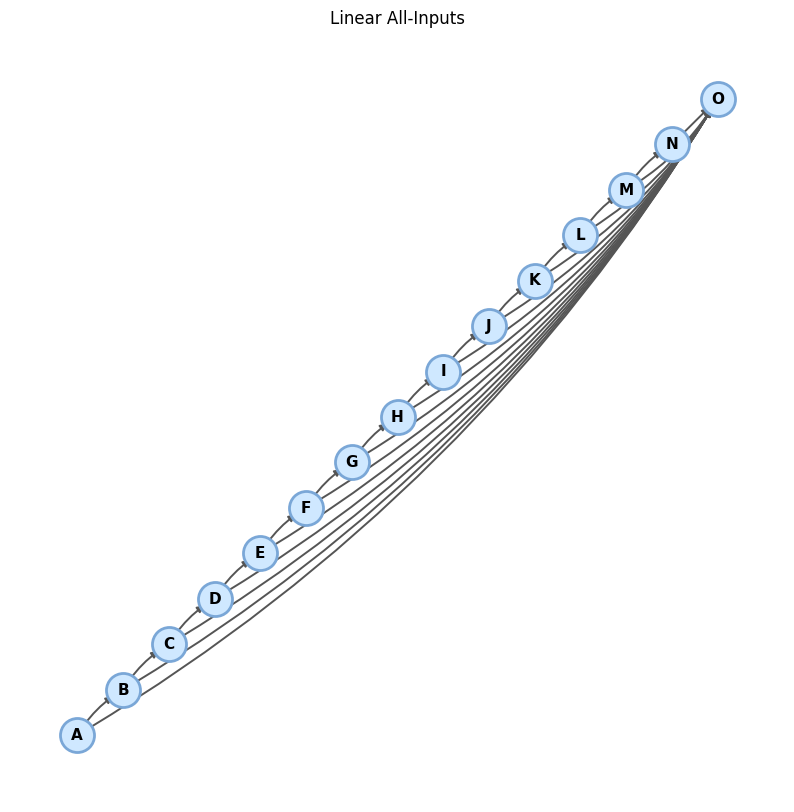

{'name': 'Linear All-Inputs',
 'nodes': 15,
 'edges': 27,
 'dag_density': 0.12857142857142856,
 'longest_path_length': 14,
 'max_betweenness_node': 'G',
 'max_betweenness_value': 0.23076923076923078,
 'outdeg_std': np.float64(0.5416025603090641),
 'sink_count': 1,
 'sink': 'O',
 'ICS_raw': np.float64(14.5186745950157),
 'figure_path': 'figs\\Linear_All-Inputs.png'}

In [57]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] =[
   
    ("A","B"), ("B","C"), ("C","D"), ("D","E"), ("E","F"),
    ("F","G"), ("G","H"), ("H","I"), ("I","J"), ("J","K"),
    ("K","L"), ("L","M"), ("M","N"), ("N","O"),
    
    ("A","O"), ("B","O"), ("C","O"), ("D","O"), ("E","O"),
    ("F","O"), ("G","O"), ("H","O"), ("I","O"), ("J","O"),
    ("K","O"), ("L","O"), ("M","O"),]

report = record_case("Linear All-Inputs", G_links) 
report

# Assembly Tree

### Structure:
A branched, two-layer assembly that converges to a single final good O. Upstream sources (A…F) feed mid-tier modules (G,H,I,J,L), which then assemble into late modules (K,M,N) before reaching O. It’s tree-like (arborescent) with limited cross-links that preserve acyclicity.

### Metrics: 
    Nodes ∣N∣: 15
    Edges ∣E∣: 25
    DAG density: 10/105 ​≈ 0.2381
    Longest path length: 4
    Max betweenness (normalized): G ≈ 0.0302

### Economic rationale:

Multiple assembly tiers create several points to recognize taxable income on inter-company transfers.

Nodes like G (highest betweenness) mediate many shortest routes to O even under comlpex structures; small mark-up changes there influence a large share of downstream profit, making this instance ideal for testing strategies.

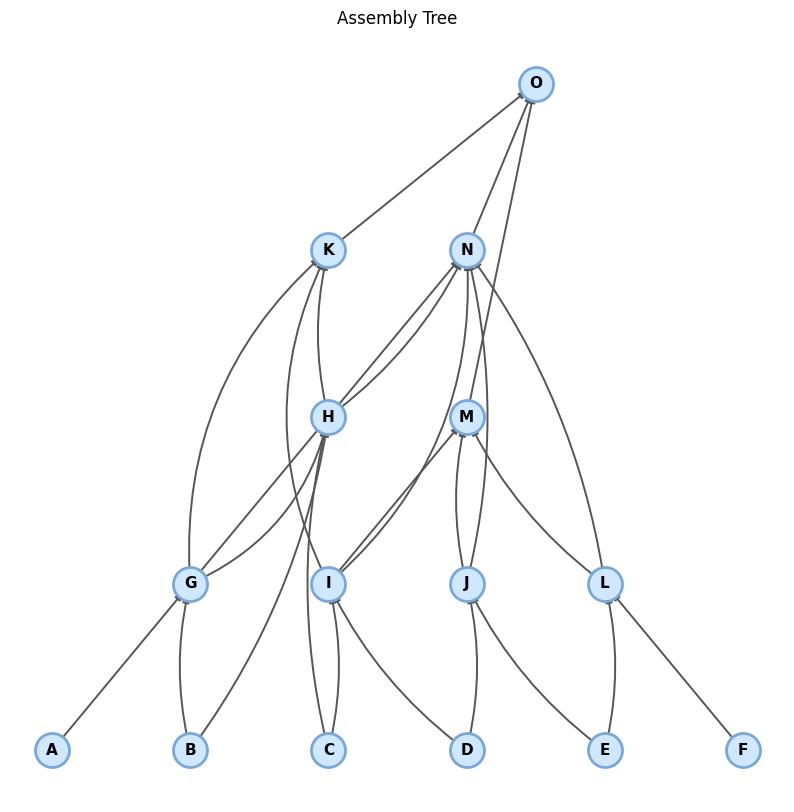

{'name': 'Assembly Tree',
 'nodes': 15,
 'edges': 25,
 'dag_density': 0.11904761904761904,
 'longest_path_length': 4,
 'max_betweenness_node': 'G',
 'max_betweenness_value': 0.030219780219780223,
 'outdeg_std': np.float64(0.7888106377466155),
 'sink_count': 1,
 'sink': 'O',
 'ICS_raw': np.float64(14.5186745950157),
 'figure_path': 'figs\\Assembly_Tree.png'}

In [58]:

G_links: List[Tuple[str, str]] = [ 
    ("A","G"), ("B","G"),      
    ("B","H"), ("C","H"),       
    ("C","I"), ("D","I"),        
    ("D","J"), ("E","J"),       
    ("I","K"), ("I","M"), ("I","N"),       
    ("E","L"), ("F","L"),       


    ("G","K"), ("H","K"), ("L","M"),  
    ("H","N"), ("J","M"), ("J","N"), 

    ("K","O"), ("N","O"),  ("M","O"),("G","N"),("L","N"),("G","H")
]
report = record_case("Assembly Tree", G_links) 
report


# Tri-Spine Convergent

### Structure:
Three independent linear production chains operate in parallel before merging through two intermediate modules into a single final good. Each early-stage path can be managed autonomously, with interconnections appearing only at advanced stages of production.


### Metrics: 
    Nodes ∣N∣: 15
    Edges ∣E∣: 15
    DAG density ​≈ 0.148
    Longest path length: 5
    Max betweenness (normalized): J ≈ 0.049

### Economic rationale:

Because the initial chains can be produced independently and later integrated through intermediate goods, firms may naturally exchange components across branches, enabling internal trade and price adjustments among related entities. This structure creates realistic opportunities for profit-shifting that are subtle and difficult to trace through conventional audit procedures.

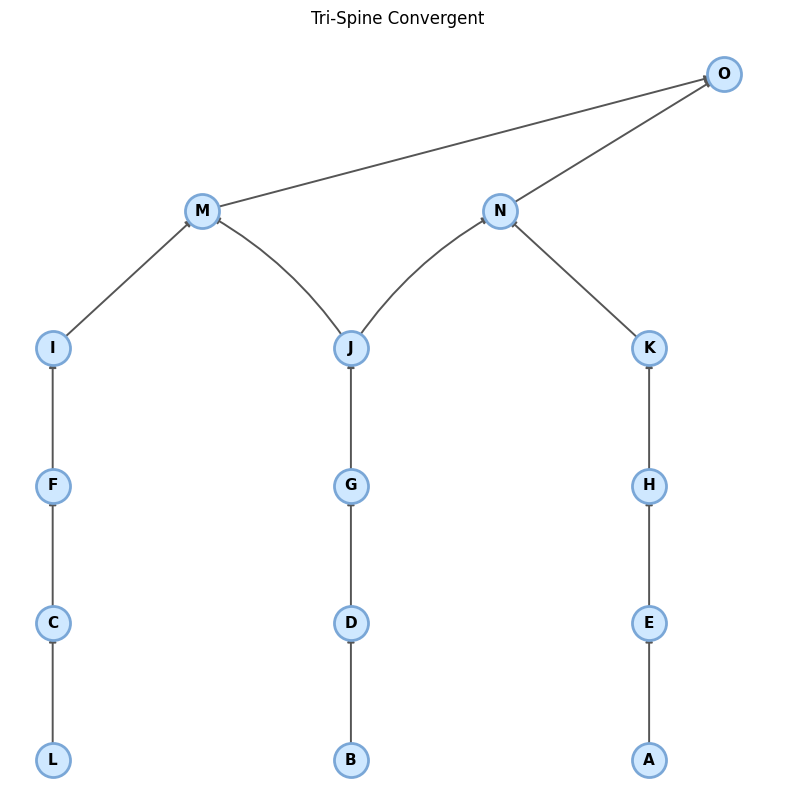

{'name': 'Tri-Spine Convergent',
 'nodes': 15,
 'edges': 15,
 'dag_density': 0.07142857142857142,
 'longest_path_length': 5,
 'max_betweenness_node': 'J',
 'max_betweenness_value': 0.049450549450549455,
 'outdeg_std': np.float64(0.3651483716701107),
 'sink_count': 1,
 'sink': 'O',
 'ICS_raw': np.float64(14.5186745950157),
 'figure_path': 'figs\\Tri-Spine_Convergent.png'}

In [59]:

G_links: List[Tuple[str, str]] = [
    
    ("L","C"),

    
    ("C","F"), ("F","I"),   
    ("B","D"), ("D","G"), ("G","J"),   
    ("A","E"), ("E","H"), ("H","K"),   

    ("I","M"), ("J","N"), ("K","N"), ("J","M"),
    ("M","O"), ("N","O")
]

report = record_case("Tri-Spine Convergent", G_links) 
report



# Sequential Mergers with External Inputs

### Structure:
Each production stage merges one internally generated good with a new external input purchased from the market, forming a chain of successive integrations that progressively build toward the final product.


### Metrics: 
    Nodes ∣N∣: 15
    Edges ∣E∣: 14
    DAG density ​≈ 0.133
    Longest path length: 7
    Max betweenness (normalized): F ≈ 0.1318

### Economic rationale:

Because every stage requires an additional good sourced from outside the current production line, firms must engage in repeated market transactions or related-party purchases. This creates a layered structure where production costs and transfer prices intertwine, offering realistic conditions for testing how external sourcing amplifies opportunities for profit-shifting and cost reallocation across entities.

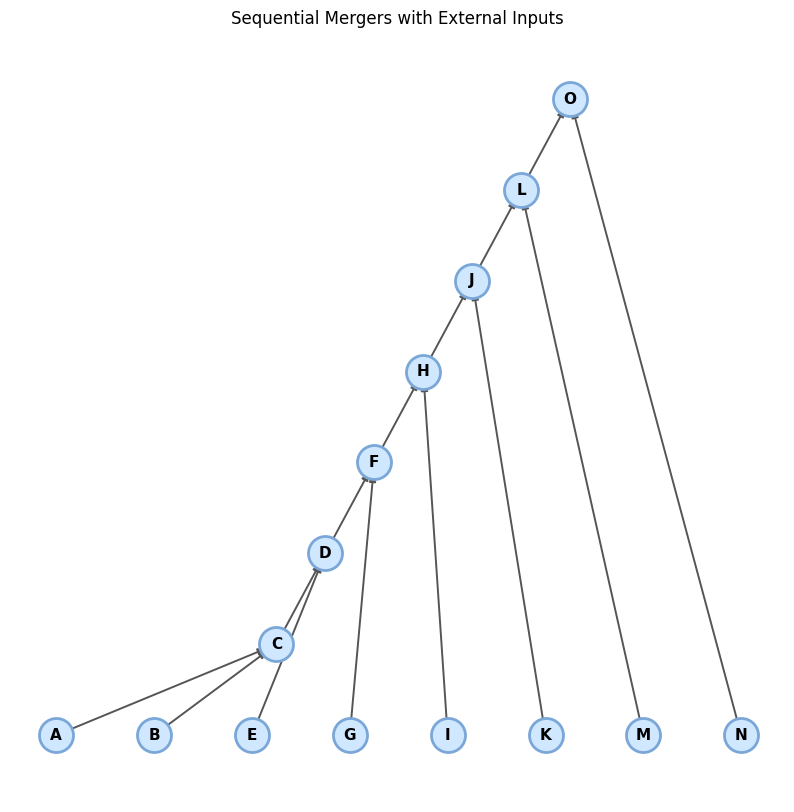

{'name': 'Sequential Mergers with External Inputs',
 'nodes': 15,
 'edges': 14,
 'dag_density': 0.06666666666666667,
 'longest_path_length': 7,
 'max_betweenness_node': 'F',
 'max_betweenness_value': 0.13186813186813187,
 'outdeg_std': np.float64(0.24944382578492943),
 'sink_count': 1,
 'sink': 'O',
 'ICS_raw': np.float64(14.5186745950157),
 'figure_path': 'figs\\Sequential_Mergers_with_External_Inputs.png'}

In [60]:
G_links: List[Tuple[str, str]] = [
    ("A","C"), ("B","C"),        
    ("C","D"), ("E","D"),        
    ("D","F"), ("G","F"),       
    ("F","H"), ("I","H"),        
    ("H","J"), ("K","J"),        
    ("J","L"), ("M","L"),        
    ("L","O"), ("N","O"),        
]


report = record_case("Sequential Mergers with External Inputs", G_links) 
report


# Butterfly

### Structure:
Every stage contains a full bipartite connection to the next, producing a dense, symmetric grid of inter-firm dependencies. Each node at a given tier can source inputs from multiple predecessors and supply multiple successors, mimicking a tightly integrated production ecosystem.


### Metrics: 
    Nodes ∣N∣: 15
    Edges ∣E∣: 14
    DAG density ​≈ 0.133
    Longest path length: 7
    Max betweenness (normalized): F ≈ 0.1318

### Economic rationale:

This configuration reproduces complex value chains where goods and capital circulate through overlapping ownership structures. The redundancy of routes allows firms to reassign production flows and internal prices across many equivalent paths, enabling high flexibility for cost shifting and margin reallocation—conditions under which profit-shifting detection becomes especially challenging.

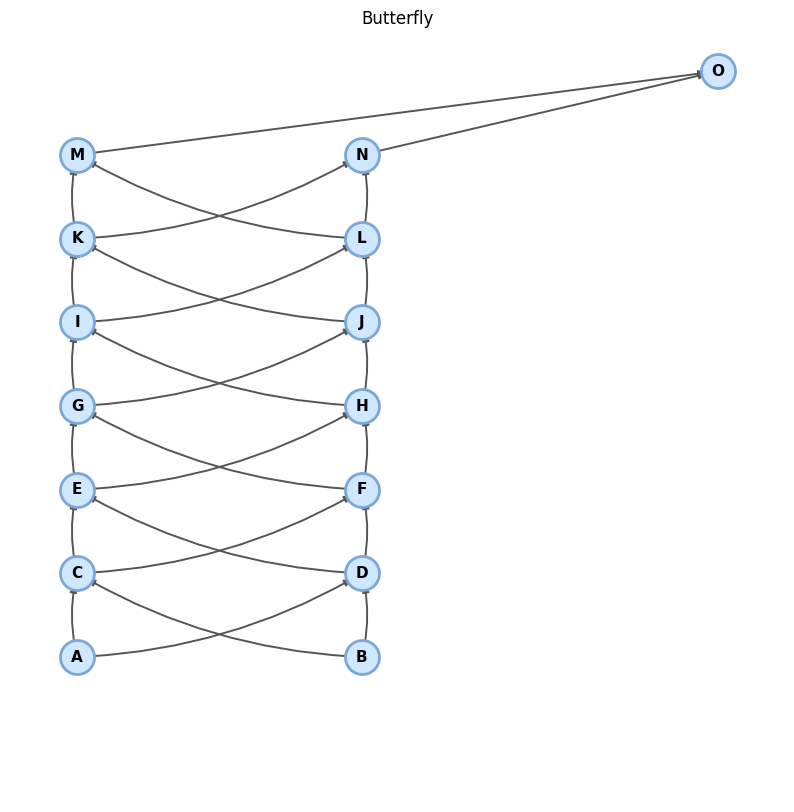

{'name': 'Butterfly',
 'nodes': 15,
 'edges': 26,
 'dag_density': 0.12380952380952381,
 'longest_path_length': 7,
 'max_betweenness_node': 'G',
 'max_betweenness_value': 0.11538461538461539,
 'outdeg_std': np.float64(0.5734883511361751),
 'sink_count': 1,
 'sink': 'O',
 'ICS_raw': np.float64(14.5186745950157),
 'figure_path': 'figs\\Butterfly.png'}

In [61]:
G_links: List[Tuple[str, str]] = [
        ("A","C"), ("A","D"), ("B","C"), ("B","D"),
        ("C","E"), ("C","F"), ("D","E"), ("D","F"),
        ("E","G"), ("E","H"), ("F","G"), ("F","H"),
        ("G","I"), ("G","J"), ("H","I"), ("H","J"),
        ("I","K"), ("I","L"), ("J","K"), ("J","L"),
        ("K","M"), ("K","N"), ("L","M"), ("L","N"),
        ("M","O"), ("N","O"),
    ]

report = record_case("Butterfly", G_links) 
report



# Tri-Cluster

### Structure:
Three independent production clusters—each internally dense and self-sufficient—operate in parallel before converging into a single coordination node that outputs the final good. Each cluster combines multiple low-level transformations before integration at the top.


### Metrics: 
    Nodes ∣N∣: 15
    Edges ∣E∣: 18
    DAG density ​≈ 0.1714
    Longest path length: 4
    Max betweenness (normalized): N ≈ 0.0714

### Economic rationale:

Because each production branch contains complex internal transformations before convergence, firms may specialize in distinct subchains and later exchange semi-finished goods among them. This setup reproduces multi-division production groups where internal markets arise n4aturally, providing an ideal testbed for analyzing multi-layer profit-shifting and the emergence of hidden intra-group trade channels.

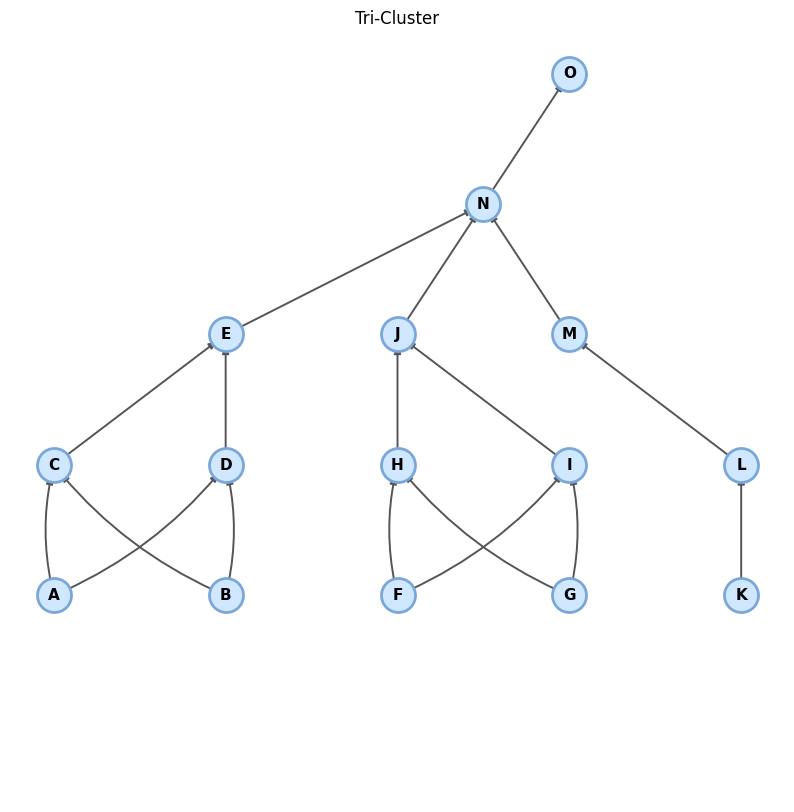

{'name': 'Tri-Cluster',
 'nodes': 15,
 'edges': 18,
 'dag_density': 0.08571428571428572,
 'longest_path_length': 4,
 'max_betweenness_node': 'N',
 'max_betweenness_value': 0.07142857142857144,
 'outdeg_std': np.float64(0.5416025603090641),
 'sink_count': 1,
 'sink': 'O',
 'ICS_raw': np.float64(14.5186745950157),
 'figure_path': 'figs\\Tri-Cluster.png'}

In [62]:
G_links: List[Tuple[str, str]] = [
  ("A","C"), ("A","D"), ("B","C"), ("B","D"), ("C","E"), ("D","E"),
  ("F","H"), ("F","I"), ("G","H"), ("G","I"), ("H","J"), ("I","J"),
  ("K","L"), ("L","M"),
  ("E","N"), ("J","N"), ("M","N"),
  ("N","O")
]

report = record_case("Tri-Cluster", G_links) 
report


# Hyper-Dense

### Structure:
An almost fully interconnected hierarchy where each layer of firms maintains trade links with nearly all nodes in subsequent layers. Multiple overlapping routes connect every stage to the final output, creating extreme redundancy and interdependence across the entire system.


### Metrics: 
    Nodes ∣N∣: 15
    Edges ∣E∣: 92
    DAG density ​≈ 0.876
    Longest path length: 5
    Max betweenness (normalized): A,... ≈ 0.0

### Economic rationale:

This highly connected configuration emulates a conglomerate-like economy in which production, sourcing, and assembly occur through a dense web of internal exchanges. Such density amplifies the degrees of freedom for price manipulation, cost reallocation, and profit-shifting—making it an ideal stress test for the model’s ability to detect evasive behaviors in environments where traditional audit trails lose clarity due to excessive interlinkages.

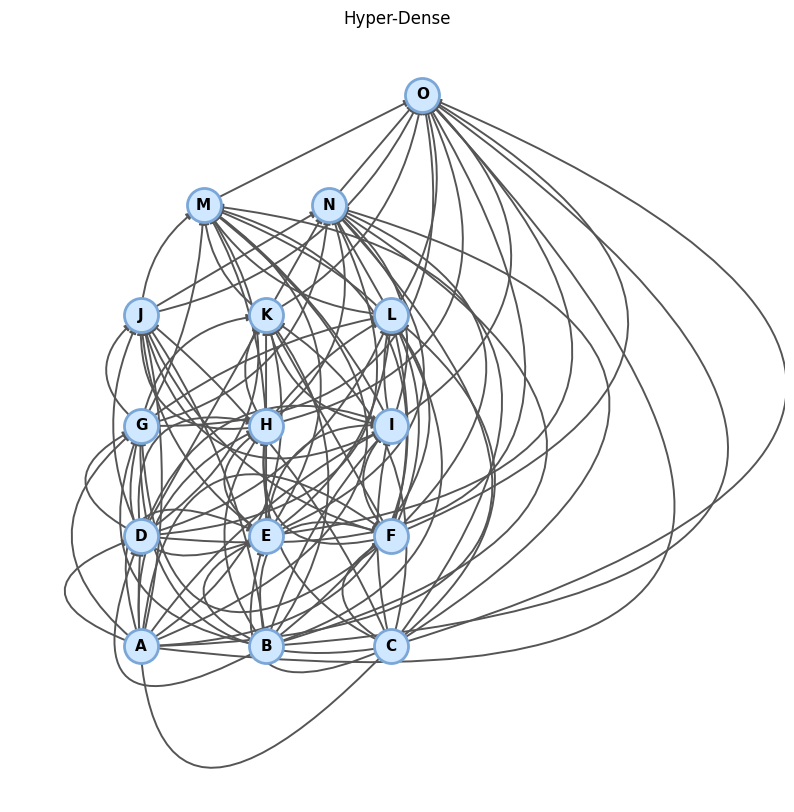

{'name': 'Hyper-Dense',
 'nodes': 15,
 'edges': 92,
 'dag_density': 0.4380952380952381,
 'longest_path_length': 5,
 'max_betweenness_node': 'A',
 'max_betweenness_value': 0.0,
 'outdeg_std': np.float64(4.063933507767512),
 'sink_count': 1,
 'sink': 'O',
 'ICS_raw': np.float64(14.5186745950157),
 'figure_path': 'figs\\Hyper-Dense.png'}

In [63]:
G_links: List[Tuple[str, str]] = [
  # L0 -> L1
  ("A","D"), ("A","E"), ("A","F"),
  ("B","D"), ("B","E"), ("B","F"),
  ("C","D"), ("C","E"), ("C","F"),

  # L0 -> L2
  ("A","G"), ("A","H"), ("A","I"),
  ("B","G"), ("B","H"), ("B","I"),
  ("C","G"), ("C","H"), ("C","I"),

  # L0 -> L3
  ("A","J"), ("A","K"), ("A","L"),
  ("B","J"), ("B","K"), ("B","L"),
  ("C","J"), ("C","K"), ("C","L"),

  # L0 -> L4
  ("A","M"), ("A","N"),
  ("B","M"), ("B","N"),
  ("C","M"), ("C","N"),

  # L0 -> L5
  ("A","O"), ("B","O"), ("C","O"),

  # L1 -> L2
  ("D","G"), ("D","H"), ("D","I"),
  ("E","G"), ("E","H"), ("E","I"),
  ("F","G"), ("F","H"), ("F","I"),

  # L1 -> L3
  ("D","J"), ("D","K"), ("D","L"),
  ("E","J"), ("E","K"), ("E","L"),
  ("F","J"), ("F","K"), ("F","L"),

  # L1 -> L4
  ("D","M"), ("D","N"),
  ("E","M"), ("E","N"),
  ("F","M"), ("F","N"),

  # L1 -> L5
  ("D","O"), ("E","O"), ("F","O"),

  # L2 -> L3
  ("G","J"), ("G","K"), ("G","L"),
  ("H","J"), ("H","K"), ("H","L"),
  ("I","J"), ("I","K"), ("I","L"),

  # L2 -> L4
  ("G","M"), ("G","N"),
  ("H","M"), ("H","N"),
  ("I","M"), ("I","N"),

  # L2 -> L5
  ("G","O"), ("H","O"), ("I","O"),

  # L3 -> L4
  ("J","M"), ("J","N"),
  ("K","M"), ("K","N"),
  ("L","M"), ("L","N"),

  # L3 -> L5
  ("J","O"), ("K","O"), ("L","O"),

  # L4 -> L5
  ("M","O"), ("N","O"),
]

report = record_case("Hyper-Dense", G_links) 
report



# All Inputs

### Structure:
A single final assembler (O) receives inputs directly from numerous independent producers, forming a pure star topology where all production paths converge in one step without intermediate processing.


### Metrics: 
    Nodes ∣N∣: 15
    Edges ∣E∣: 14
    DAG density ​≈ 0.1333
    Longest path length: 1
    Max betweenness (normalized): A,... ≈ 0.0

### Economic rationale:

This configuration represents a centralized assembly or procurement structure—common in large holding companies or anchor firms sourcing from multiple subsidiaries. It serves as a baseline case to evaluate how profit recognition concentrates at the central node and how limited inter-firm trade reduces, but does not eliminate, opportunities for cost misallocation or transfer-price manipulation through direct supplier relationships.

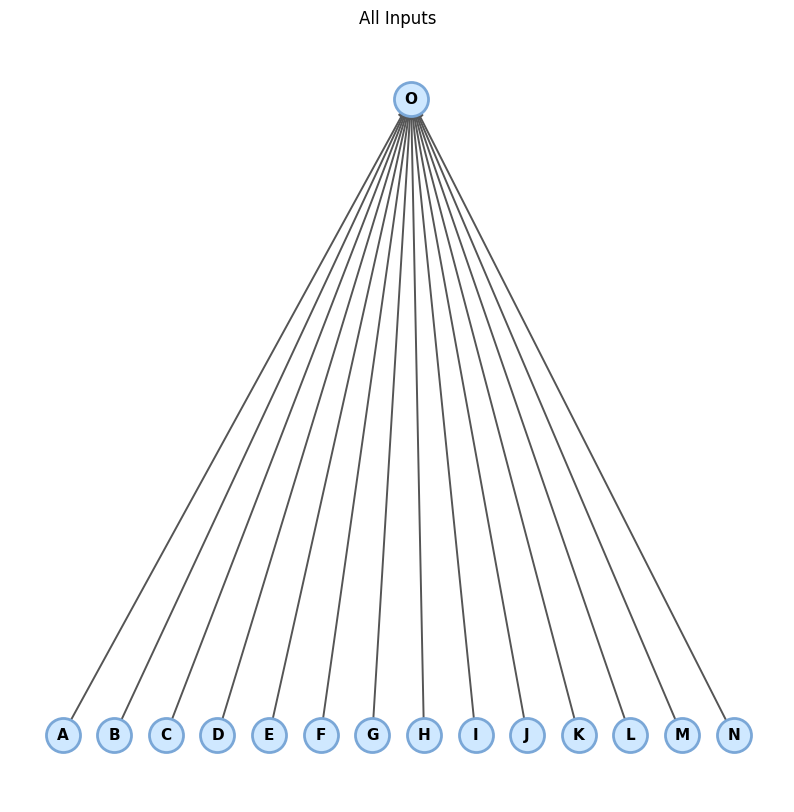

{'name': 'All Inputs',
 'nodes': 15,
 'edges': 14,
 'dag_density': 0.06666666666666667,
 'longest_path_length': 1,
 'max_betweenness_node': 'A',
 'max_betweenness_value': 0.0,
 'outdeg_std': np.float64(0.24944382578492946),
 'sink_count': 1,
 'sink': 'O',
 'ICS_raw': np.float64(14.5186745950157),
 'figure_path': 'figs\\All_Inputs.png'}

In [64]:
G_links: List[Tuple[str, str]] = [
  ("A","O"), ("B","O"), ("C","O"), ("D","O"), ("E","O"),
  ("F","O"), ("G","O"), ("H","O"), ("I","O"), ("J","O"),
  ("K","O"), ("L","O"), ("M","O"), ("N","O")
]

report = record_case("All Inputs", G_links) 
report


# Mangrove

### Structure:
Interwoven roots of partially overlapping production chains converge and diverge repeatedly before reaching the final output. Multiple upstream nodes feed shared intermediates, creating loops of partial dependency that resemble the tangled structure of a mangrove.


### Metrics: 
    Nodes ∣N∣: 15
    Edges ∣E∣: 31
    DAG density ​≈ 0.2952
    Longest path length: 5
    Max betweenness (normalized): M ≈ 0.0714

### Economic rationale:

This graph captures the dynamics of inter-firm production systems where inputs and semi-finished goods circulate across overlapping branches. Such entanglement generates multiple plausible transfer routes and ownership boundaries, allowing firms to redistribute profits across interconnected subsidiaries while maintaining operational legitimacy—making it a powerful test case for tracing concealed profit flows within dense, semi-circular supply webs.

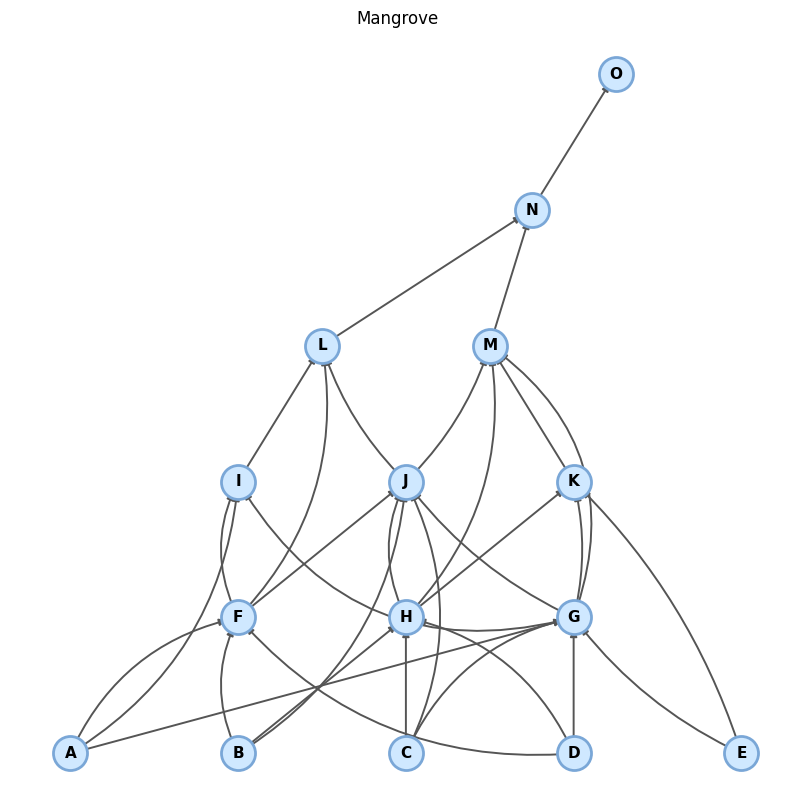

{'name': 'Mangrove',
 'nodes': 15,
 'edges': 31,
 'dag_density': 0.14761904761904762,
 'longest_path_length': 5,
 'max_betweenness_node': 'M',
 'max_betweenness_value': 0.07417582417582418,
 'outdeg_std': np.float64(1.1234866364235145),
 'sink_count': 1,
 'sink': 'O',
 'ICS_raw': np.float64(14.5186745950157),
 'figure_path': 'figs\\Mangrove.png'}

In [65]:
G_links: List[Tuple[str, str]] = [
  ("A","F"), ("A","G"), ("A","I"),
  ("B","F"), ("B","H"), ("B","J"),
  ("C","G"), ("C","H"), ("C","J"),
  ("D","F"), ("D","G"), ("D","H"),
  ("E","G"), ("E","K"),

  ("F","I"), ("F","J"), ("F","L"),
  ("G","I"), ("G","J"), ("G","K"), ("G","M"),
  ("H","J"), ("H","K"), ("H","M"),

  ("I","L"),
  ("J","L"), ("J","M"),
  ("K","M"),

  ("L","N"), ("M","N"),
  ("N","O")
]

report = record_case("Mangrove", G_links) 
report


# Dominant Input

### Structure:
A single dominant input (A) feeds every stage of production while a secondary linear chain (B→C→…→O) propagates sequential transformations. The structure mixes a hierarchical dependency on one key input with a serial progression of value addition.


### Metrics: 
    Nodes ∣N∣: 15
    Edges ∣E∣: 27
    DAG density ​≈ 0.2571
    Longest path length: 14
    Max betweenness (normalized): H ≈ 0.2307

### Economic rationale:

This configuration represents industries centered around a pivotal raw material or proprietary asset that participates in all production stages—such as technology, licensing, or energy inputs. It allows the model to test how dependency on a dominant supplier shapes internal pricing and how control over a critical input can be used to shift profits along the production chain through strategic transfer pricing.

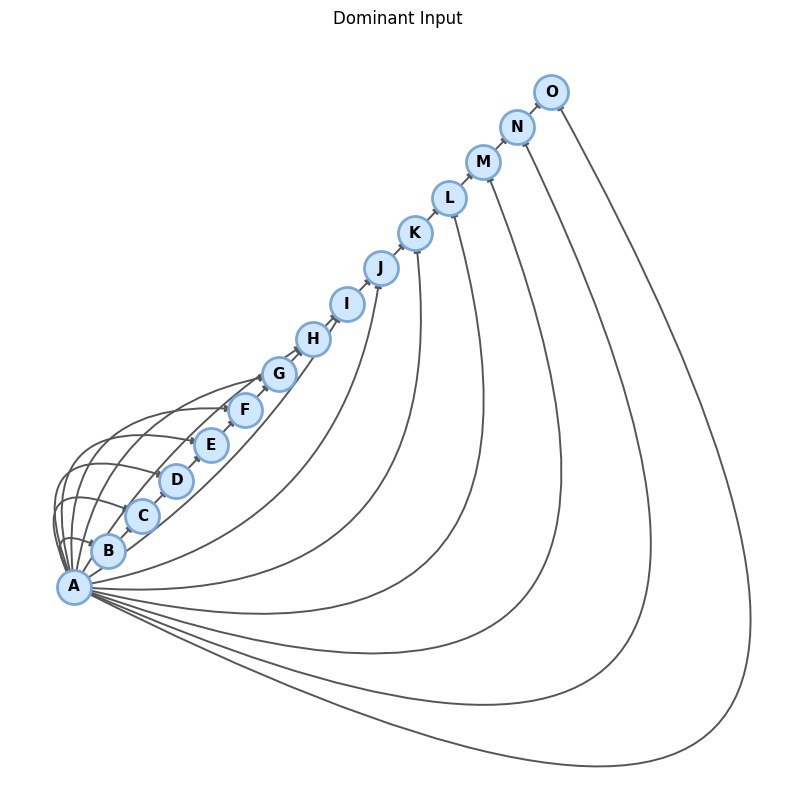

{'name': 'Dominant Input',
 'nodes': 15,
 'edges': 27,
 'dag_density': 0.12857142857142856,
 'longest_path_length': 14,
 'max_betweenness_node': 'H',
 'max_betweenness_value': 0.23076923076923078,
 'outdeg_std': np.float64(3.270066258248191),
 'sink_count': 1,
 'sink': 'O',
 'ICS_raw': np.float64(14.5186745950157),
 'figure_path': 'figs\\Dominant_Input.png'}

In [66]:
G_links: List[Tuple[str, str]] = [
  ("A","B"), ("A","C"), ("A","D"), ("A","E"), ("A","F"),
  ("A","G"), ("A","H"), ("A","I"), ("A","J"), ("A","K"),
  ("A","L"), ("A","M"), ("A","N"), ("A","O"),

  ("B","C"), ("C","D"), ("D","E"), ("E","F"),
  ("F","G"), ("G","H"), ("H","I"), ("I","J"),
  ("J","K"), ("K","L"), ("L","M"), ("M","N"), ("N","O")
]

report = record_case("Dominant Input", G_links) 
report


# Successive Diamonds

### Structure:
A sequence of interconnected diamond-shaped modules where each stage of production splits into parallel subpaths and later reconverges before moving upstream. This layered symmetry generates multiple routes between distant nodes while preserving a clear global direction of flow.


### Metrics: 
    Nodes ∣N∣: 15
    Edges ∣E∣: 22
    DAG density ​≈ 0.2095
    Longest path length: 5
    Max betweenness (normalized): L ≈ 0.0752

### Economic rationale:

The diamond architecture models production systems with repeated joint ventures or subcontracting arrangements, where parallel entities perform similar transformations before consolidation. Each merge–split cycle multiplies the number of potential pricing interfaces, creating a rich environment to test how firms can alternate between competition and collaboration to obscure value creation points and enable nuanced forms of profit-shifting across sequential stages.

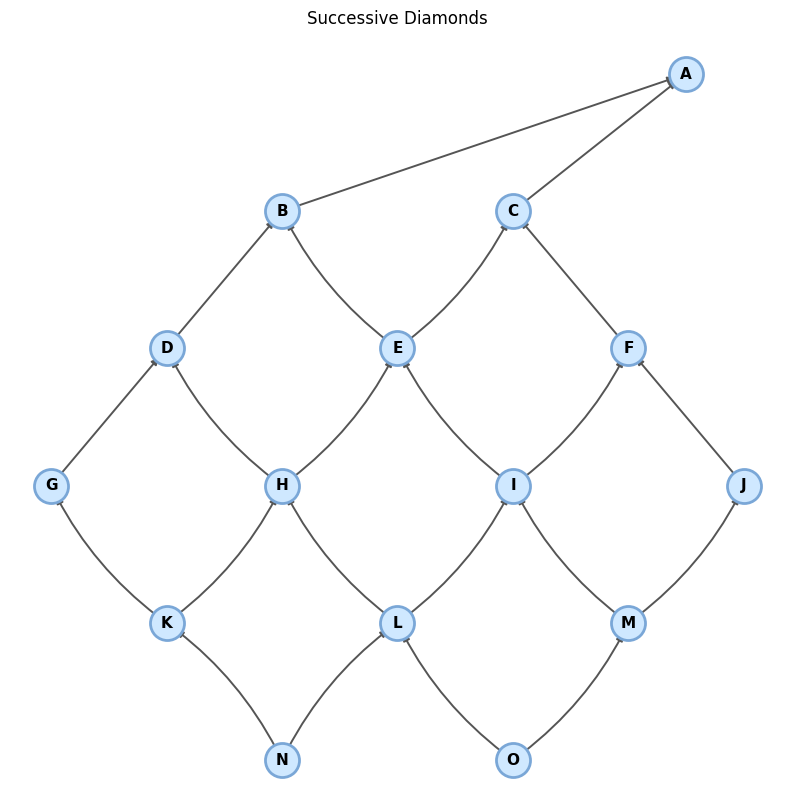

{'name': 'Successive Diamonds',
 'nodes': 15,
 'edges': 22,
 'dag_density': 0.10476190476190476,
 'longest_path_length': 5,
 'max_betweenness_node': 'E',
 'max_betweenness_value': 0.07527472527472527,
 'outdeg_std': np.float64(0.6182412330330469),
 'sink_count': 1,
 'sink': 'A',
 'ICS_raw': np.float64(14.5186745950157),
 'figure_path': 'figs\\Successive_Diamonds.png'}

In [67]:
 # Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [ 
    ("N","L"),
    ("O","L"),
    ("O","M"),
    ("N","K"),
    ("N","L"),
    ("K","G"),
    ("K","H"),
    ("L","H"),
    ("L","I"),
    ("M","I"),
    ("M","J"),
    ("G","D"),
    ("H","D"),
    ("H","E"),
    ("I","E"),
    ("I","F"),
    ("J","F"),
    ("D","B"),
    ("E","B"),
    ("E","C"),
    ("F","C"),
    ("B","A"),
    ("C","A")]

report = record_case("Successive Diamonds", G_links) 
report



# Interlaced Pathway

### Structure:
A deep, asymmetrical hierarchy where multiple partially overlapping chains form a dense web of forward and backward interconnections. Parallel paths repeatedly merge and diverge, producing a structure that balances hierarchy and lateral exchange.


### Metrics: 
    Nodes ∣N∣: 15
    Edges ∣E∣: 23
    DAG density ​≈ 0.2190
    Longest path length: 12
    Max betweenness (normalized): L ≈ 0.1139

### Economic rationale:

This configuration resembles a multi-division production ecosystem with recursive sourcing between intermediate stages. Firms at similar levels can transact both vertically and horizontally, allowing for strategic reallocation of profits through reciprocal pricing.

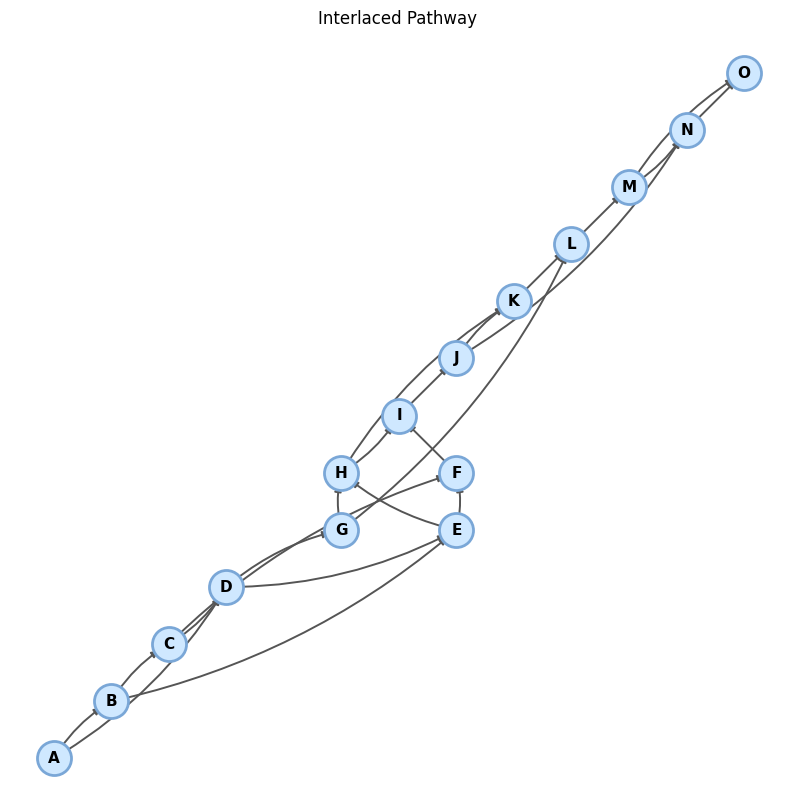

{'name': 'Interlaced Pathway',
 'nodes': 15,
 'edges': 23,
 'dag_density': 0.10952380952380952,
 'longest_path_length': 12,
 'max_betweenness_node': 'L',
 'max_betweenness_value': 0.11391941391941393,
 'outdeg_std': np.float64(0.6182412330330469),
 'sink_count': 1,
 'sink': 'O',
 'ICS_raw': np.float64(14.5186745950157),
 'figure_path': 'figs\\Interlaced_Pathway.png'}

In [68]:
G_links: List[Tuple[str, str]] = [ 
    ("A","B"), 
    ("B","C"), 
    ("C","F"), 
    ("A","D"), 
    ("D","G"), 
    ("D","E"), 
    ("E","H"), 
    ("E","F"), 
    ("F","I"), 
    ("I","J"), 
    ("J","K"), 
    ("J","N"), 
    ("H","K"), 
    ("G","H"), 
    ("G","L"), 
    ("L","M"), 
    ("M","O"), 
    ("M","N"),
    ("N","O"), 
    ("B","E"),
    ("C","D"),
    ("K","L"),
    ("H","I")]


report = record_case("Interlaced Pathway", G_links) 
report


# Explosive Expansion

### Structure:
A branching hierarchy where each production stage multiplies into several independent subpaths that ultimately converge in a single final output. The process expands rapidly from a few initial inputs into a wide array of intermediates before collapsing back into one assembler.


### Metrics: 
    Nodes ∣N∣: 15
    Edges ∣E∣: 20
    DAG density ​≈ 0.1904
    Longest path length: 4
    Max betweenness (normalized): B ≈ 0.036

### Economic rationale:

This structure represents industries with high product diversification and distributed intermediate production—such as component manufacturing or modular assembly chains. The rapid branching amplifies the number of entities and internal transactions, providing fertile ground for hidden mark-ups and complex transfer-pricing patterns as profits can be dispersed among many nodes before consolidation.

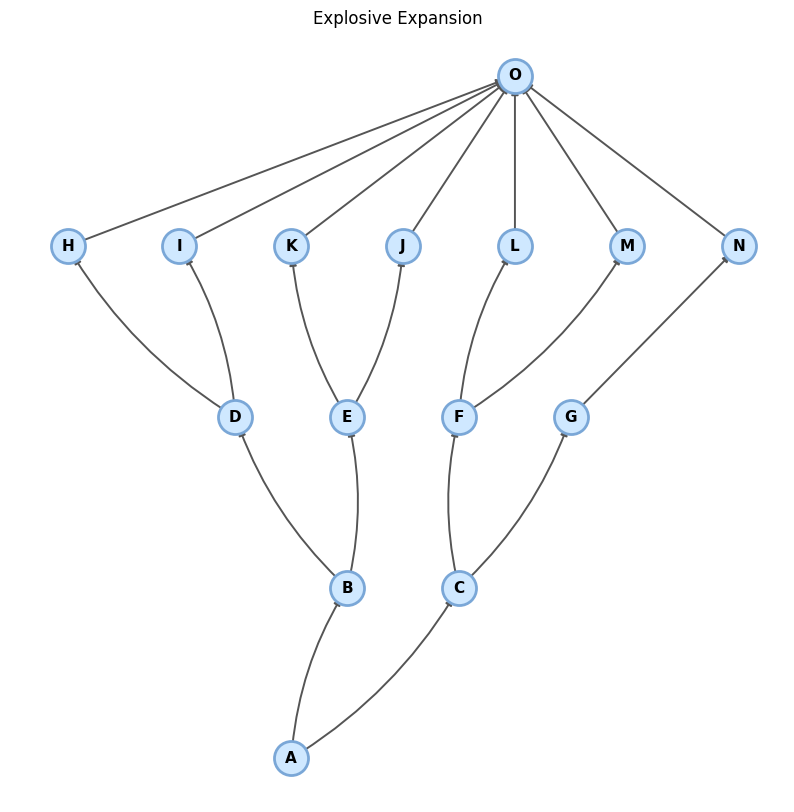

{'name': 'Explosive Expansion',
 'nodes': 15,
 'edges': 20,
 'dag_density': 0.09523809523809523,
 'longest_path_length': 4,
 'max_betweenness_node': 'B',
 'max_betweenness_value': 0.03610675039246468,
 'outdeg_std': np.float64(0.5962847939999439),
 'sink_count': 1,
 'sink': 'O',
 'ICS_raw': np.float64(14.5186745950157),
 'figure_path': 'figs\\Explosive_Expansion.png'}

In [69]:
G_links: List[Tuple[str, str]] = [ 
    ("A","B"), 
    ("A","C"), 
    ("B","D"), 
    ("B","E"), 
    ("C","F"), 
    ("C","G"), 
    ("D","H"), 
    ("D","I"), 
    ("E","K"), 
    ("E","J"), 
    ("F","L"), 
    ("F","M"), 
    ("G","N"), 
    ("H","O"), 
    ("I","O"), 
    ("J","O"), 
    ("K","O"), 
    ("L","O"),
    ("M","O"), 
    ("N","O")]

report = record_case("Explosive Expansion", G_links) 
report


# All in one

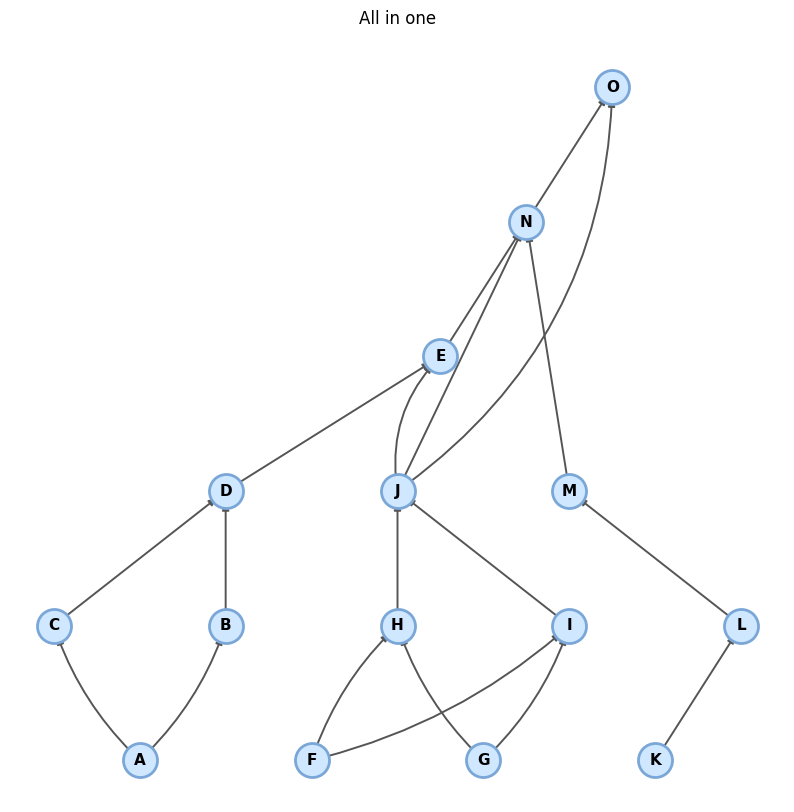

{'name': 'All in one',
 'nodes': 15,
 'edges': 19,
 'dag_density': 0.09047619047619047,
 'longest_path_length': 5,
 'max_betweenness_node': 'J',
 'max_betweenness_value': 0.06593406593406594,
 'outdeg_std': np.float64(0.679869268479038),
 'sink_count': 1,
 'sink': 'O',
 'ICS_raw': np.float64(14.5186745950157),
 'figure_path': 'figs\\All_in_one.png'}

In [70]:
G_links: List[Tuple[str, str]] = [
  ("A","C"), ("B","D"), ("C","D"), ("D","E"),("A","B"), ("J","E"),
  ("F","H"), ("F","I"), ("G","H"), ("G","I"), ("H","J"), ("I","J"),
  ("K","L"), ("L","M"),
  ("E","N"), ("J","N"), ("M","N"),("J","O"),
  ("N","O")
]

report = record_case("All in one", G_links) 
report


In [71]:
Edge = Tuple[str, str]

G_links: List[Edge] = [ 
    ("A","B"), 
    ("A","C"), 
    ("B","D"), 
    ("B","E"), 
    ("C","F"), 
    ("C","G"), 
    ("D","H"), 
    ("D","I"), 
    ("E","K"), 
    ("E","J"), 
    ("F","L"), 
    ("F","M"), 
    ("G","N"), 
    ("H","O"), 
    ("I","O"), 
    ("J","O"), 
    ("K","O"), 
    ("L","O"),
    ("M","O"), 
    ("N","O")]

report = profile_graph(G_links, label="A")
print(report)

# (Opcional) sanity checks
G = nx.DiGraph(); G.add_edges_from(G_links)
assert nx.is_directed_acyclic_graph(G)
sinks = [u for u in G if G.out_degree(u) == 0]
assert len(sinks) == 1 and sinks[0] == "O"

{'name': 'A', 'nodes': 15, 'edges': 20, 'dag_density': 0.09523809523809523, 'longest_path_length': 4, 'max_betweenness_node': 'B', 'max_betweenness_value': 0.03610675039246468, 'outdeg_std': np.float64(0.5962847939999439), 'sink_count': 1, 'sink': 'O', 'ICS_raw': np.float64(14.5186745950157)}


In [72]:
summary_df = cases_summary(as_dataframe=True)
display(summary_df)

summary_path = OUT_DIR / "graphs_summary.csv"
summary_df.to_csv(summary_path, index=False)
summary_path


,name,nodes,edges,dag_density,longest_path_length,max_betweenness_node,max_betweenness_value,outdeg_std,sink_count,sink,ICS_raw
0,Linear,15,14,0.066667,14,H,0.269231,0.249444,1,O,14.518675
1,Linear All-Inputs,15,27,0.128571,14,G,0.230769,0.541603,1,O,14.518675
2,Assembly Tree,15,25,0.119048,4,G,0.030220,0.788811,1,O,14.518675
3,Tri-Spine Convergent,15,15,0.071429,5,J,0.049451,0.365148,1,O,14.518675
4,Sequential Mergers with External Inputs,15,14,0.066667,7,F,0.131868,0.249444,1,O,14.518675
5,Butterfly,15,26,0.123810,7,G,0.115385,0.573488,1,O,14.518675
6,Tri-Cluster,15,18,0.085714,4,N,0.071429,0.541603,1,O,14.518675
7,Hyper-Dense,15,92,0.438095,5,A,0.000000,4.063934,1,O,14.518675
8,All Inputs,15,14,0.066667,1,A,0.000000,0.249444,1,O,14.518675
9,Mangrove,15,31,0.147619,5,M,0.074176,1.123487,1,O,14.518675


WindowsPath('figs/graphs_summary.csv')